In [1]:
from pathlib import Path
import sys

# Make repo root importable (so `import main` works)
repo_root = Path.cwd().parent  # notebook dir -> project root
sys.path.insert(0, str(repo_root))

from main import reimport
import warnings
warnings.filterwarnings('ignore')

from Steady_state_equilibrium.SS_Solver import SteadyStateEquilibrium
from Calibration.Labour_func import build_target_labour_profile, calibrate_chi

import numpy as np
import pandas as pd
import scipy.interpolate as si
from matplotlib import pyplot as plt

## Демография

In [2]:
omega = pd.read_excel(
    '../Data/total_pop.xlsx'
) # in thousands

omega.set_index('Year', inplace=True)
omega /= 1000 # now in mils
omega.head()

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
2024,1.277417,1.312895,1.380561,1.446116,1.487208,1.567881,1.670708,1.810267,1.930952,1.949820,...,0.140585,0.126703,0.107781,0.087376,0.066252,0.048631,0.032987,0.021349,0.013078,0.016232
2025,1.246285,1.271581,1.308049,1.376177,1.442105,1.483526,1.564484,1.667557,1.807322,1.928187,...,0.127439,0.115805,0.102549,0.085620,0.068076,0.050547,0.036274,0.024023,0.015157,0.020228
2026,1.224295,1.246173,1.271931,1.308417,1.376515,1.442405,1.483793,1.564708,1.667729,1.807435,...,0.148059,0.105124,0.093856,0.081592,0.066803,0.052020,0.037760,0.026459,0.017086,0.024442
2027,1.210562,1.230467,1.252234,1.277520,1.313540,1.381201,1.446697,1.487726,1.568304,1.671013,...,0.177382,0.122317,0.085336,0.074790,0.063772,0.051130,0.038931,0.027589,0.018855,0.028696
2028,1.199379,1.216619,1.236402,1.257707,1.282536,1.318133,1.385408,1.450549,1.491254,1.571531,...,0.212148,0.146734,0.099436,0.068107,0.058541,0.048891,0.038321,0.028490,0.019689,0.032850


In [3]:
def get_mort(totpers):
    data = pd.read_excel('../Data/death_probability.xlsx')
    data.set_index('Year', inplace=True)
    mort = pd.DataFrame(index=data.index, columns=np.arange(totpers)+1)
    for i, year in enumerate(data.index):
        mort_data = data.iloc[i, :]
        mort_data.loc[-1] = 0.
        mort_data.loc[-2] = 0.
        mort_data.loc[totpers+1] = 1.
        mort_data.loc[totpers+2] = 1.

        age_midp = mort_data.index.values

        fit_mort = si.interp1d(age_midp, mort_data, kind='cubic', bounds_error=False, fill_value=0)

        age_model = np.linspace(100 / totpers, 100, totpers) - (0.5 * 100 / totpers)
        mort_model = fit_mort(age_model)
        fit = fit_mort(np.linspace(0, 100, 1000))

        mort.loc[year] = mort_model
    return mort[(mort >= 0.)&(mort <= 1.)].ffill(axis=1)

In [4]:
rho = get_mort(100)
rho.head()

,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
2024,0.003242,0.003242,0.003242,0.003242,0.000187,0.001342,0.001802,0.001770,0.001474,0.001144,...,0.653907,0.677657,0.702053,0.730243,0.765375,0.810375,0.863029,0.915987,0.961673,0.992514
2025,0.003108,0.003108,0.003108,0.003108,0.000189,0.001294,0.001734,0.001704,0.001422,0.001110,...,0.651599,0.675440,0.699936,0.728264,0.763605,0.808912,0.861955,0.915320,0.961366,0.992454
2026,0.002977,0.002977,0.002977,0.002977,0.000191,0.001247,0.001667,0.001639,0.001371,0.001076,...,0.648988,0.672903,0.697487,0.725956,0.761526,0.807187,0.860685,0.914530,0.961002,0.992382
2027,0.002857,0.002857,0.002857,0.002857,0.000192,0.001203,0.001606,0.001580,0.001325,0.001044,...,0.646180,0.670175,0.694863,0.723496,0.759323,0.805366,0.859348,0.913700,0.960620,0.992307
2028,0.002736,0.002736,0.002736,0.002736,0.000193,0.001159,0.001544,0.001519,0.001277,0.001011,...,0.643941,0.668056,0.692899,0.721729,0.757805,0.804153,0.858480,0.913171,0.960380,0.992260


<BarContainer object of 101 artists>

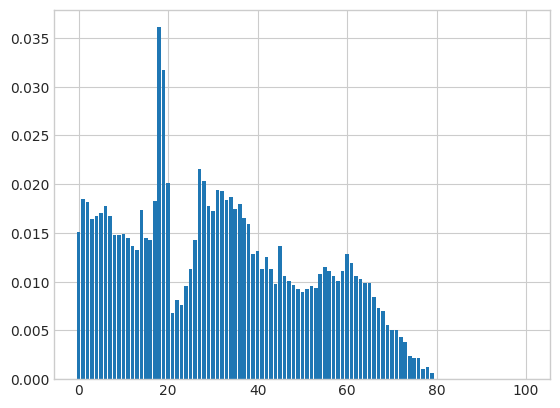

In [5]:
I = pd.read_excel('../Data/age specific migration.xlsx',
                     sheet_name='migration').set_index('Year') # in thousands
I /= 1000 # now in mils
i = pd.read_excel('../Data/age specific migration.xlsx',
                     sheet_name='rate').set_index('age')
i = i['average']
plt.bar(i.index, i)

In [6]:
pops = pd.DataFrame(omega.loc[2025][:-1].values, columns=['omega'], index=range(1, 101))
pops['rho'] = rho.loc[2025].values
pops['i'] = i[:-1]
pops.to_csv('../Data/pops.csv')

## Labour augmentation

In [7]:
def get_tuple_bins(strings):
    groups = []
    for i in strings:
        i = i.replace(' ', '')
        if len(i) <= 5:
            groups.append((int(i[:2]), int(i[3:])))
        else:
            groups.append((int(i[:2]), 999))
    return groups

In [8]:
employment = pd.read_excel('../Data/employment.xlsx', header=1).iloc[-1, 2:]
employ = {group: val/100 for group, val in zip(get_tuple_bins(employment.index), employment.values)}
hours = pd.read_excel('../Data/hours.xlsx', header=2)
hours = {group: val for group, val in zip(get_tuple_bins(hours.iloc[1:, 0]), hours.iloc[1:, -1])}

In [9]:
n_target, ep_profile, hours_profile = build_target_labour_profile(
    ep_by_bin=employ,
    hours_by_bin=hours,
    h_max=100,
    E=20,
    S=100,
    tail_start_age=70,
    tail_zero_age=85,
    left_anchor_offset=6,
    return_components=True
)

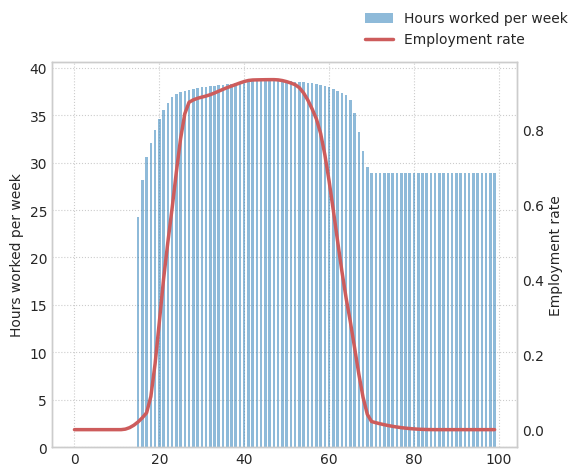

In [9]:
hours_profile[:15] = 0
ep_profile[:12] = 0

fig, ax1 = plt.subplots(figsize=[6,5])

ax2 = ax1.twinx()

ax1.bar(range(len(hours_profile)), hours_profile, color='C0', alpha=0.5,
        label='Hours worked per week', width=.6)
ax2.plot(ep_profile, color='indianred', linewidth=2.5, label='Employment rate')

ax1.set_ylabel('Hours worked per week')
ax2.set_ylabel('Employment rate')

# Grid only on ax1, ":" style, and behind the plots
ax1.grid(True, linestyle=':', zorder=0)
ax1.set_axisbelow(True)

# Make sure ax2 has no grid
ax2.grid(False)

fig.legend()
plt.savefig('/home/eurapartners.local/moiseev.kv/Repositories/tex_Thesis/src/resources/figures/chi_s_profile.png', dpi=300)

In [182]:
pd.DataFrame(n_target, columns=['n_target'], index=range(1, 101)).to_csv('../Data/n_target.csv')

In [15]:
chi_s = np.array(
    [
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.13247818e-01, 9.84292532e-02, 9.40767309e-02, 9.38748090e-02,
        9.49424187e-02, 9.86457414e-02, 1.05939417e-01, 1.18597529e-01,
        1.36289740e-01, 1.57111092e-01, 1.81513666e-01, 2.09983402e-01,
        2.43027011e-01, 2.81363897e-01, 3.26081474e-01, 3.78422962e-01,
        4.39955587e-01, 5.12638413e-01, 5.98494696e-01, 6.99999714e-01,
        8.20697280e-01, 9.65062587e-01, 1.13881759e+00, 1.34792552e+00,
        1.59896991e+00, 1.90117307e+00, 2.26559958e+00, 2.70630017e+00,
        3.24290197e+00, 3.90077165e+00, 4.71026495e+00, 5.71012939e+00,
        6.94988972e+00, 8.51935655e+00, 1.05459312e+01, 1.31745097e+01,
        1.66026329e+01, 2.10938154e+01, 2.73003453e+01, 3.63212307e+01,
        4.95823154e+01, 6.93634628e+01, 9.93313809e+01, 1.45323125e+02,
        2.16171079e+02, 3.27582239e+02, 5.41184463e+02, 9.95992174e+02,
        2.09172394e+03, 5.12846939e+03, 1.14335371e+04, 1.76037566e+04,
        2.77457129e+04, 4.49112509e+04, 7.49404330e+04, 1.29481505e+05,
        2.32888496e+05, 4.38858663e+05, 8.73286023e+05, 1.85390601e+06,
        4.25937117e+06, 1.08281554e+07, 3.16825771e+07, 1.16182831e+08,
        6.95580720e+08, 1.50641745e+10, 3.44379263e+10, 8.42889264e+10,
        2.21997443e+11, 6.31027852e+11, 1.93592625e+12, 6.38716156e+12,
        2.26210382e+13, 8.66557360e+13, 3.66563461e+14, 1.78241718e+15,
        1.07219759e+16, 8.92800388e+16, 1.21191976e+18, 3.60584864e+19
    ]
)

In [19]:
g_n = omega.loc[2025].sum() / omega.loc[2024].sum() - 1
params = {
    'A': 1.4,
    'alpha': .39,
    'delta': .05,
    'tau_c': 0.,
    'tau_l': .22,
    'tau_k': 0.,
    'R': 62,
    'E': 20,
    'S': 100,
    'g_n': g_n,
    'g_y': .054,
    'beta': .905,
    'sigma': 1.97,
    'replacement_rate': .3,
    'ltilde': 1.,
    'b_ellip': .4309,
    'upsilon': 1.7648,
    'chi_s': chi_s, #np.ones(100),
    'h': 0.0,
}
# Normalizing population to 1 for convenience
pop_base = omega.iloc[:, :].sum(axis=1)
omega_norm = omega.div(pop_base, axis=0)
I_norm = I.div(pop_base, axis=0)

vectors = {
    'omega': omega_norm.loc[2025][:-1].values,
    'rho': rho.loc[2025].values,
    'i_rate': i[:-1].values,
    'I_total': I_norm.loc[2025].values,
}

solver_params = {
    'r_guess': 0.0,
    'BQ_guess': 0.2,
    'tax_guess': .22,
    'policy_mode': 'fix_tax',
    'tax_type': 'tau_l',
    'xi': 0.4,
    'tol': 1e-2,
    'max_iter': 1000,
    'debug': False
}

reimport()
chi_s, ss_results = calibrate_chi(
    params=params,
    vectors=vectors,
    n_target=n_target,
    max_iter=50,
    tol=1e-3,
    xi_chi=.99,
    ss_solve_kwargs=solver_params,
)
ss_results

Starting Steady State Solver (Mode: fix_tax, Tax: tau_l)...
Converged in 38 iterations.
Chi-iter 0: max |dchi| = 1.013e+23, r = -0.0305, w = 7.1859
Starting Steady State Solver (Mode: fix_tax, Tax: tau_l)...
Converged in 30 iterations.
Chi-iter 1: max |dchi| = 1.640e+00, r = -0.0283, w = 6.7123
Starting Steady State Solver (Mode: fix_tax, Tax: tau_l)...
Converged in 27 iterations.
Chi-iter 2: max |dchi| = 7.654e-01, r = -0.0284, w = 6.7208
Starting Steady State Solver (Mode: fix_tax, Tax: tau_l)...
Converged in 26 iterations.
Chi-iter 3: max |dchi| = 4.453e-01, r = -0.0284, w = 6.7216
Starting Steady State Solver (Mode: fix_tax, Tax: tau_l)...


KeyboardInterrupt: 

<BarContainer object of 100 artists>

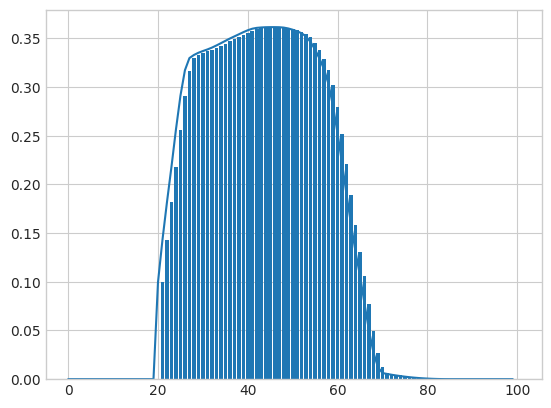

In [12]:
plt.plot(ss_results['n_vec'])
plt.bar(range(1, 101), n_target)

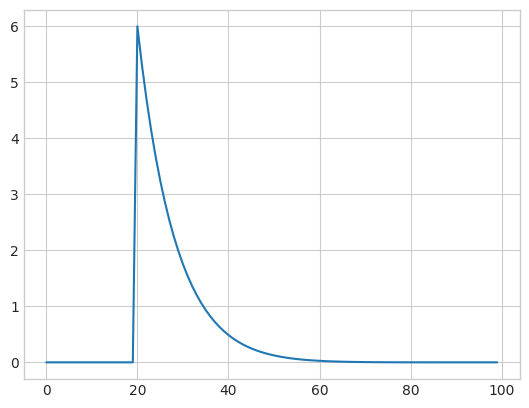

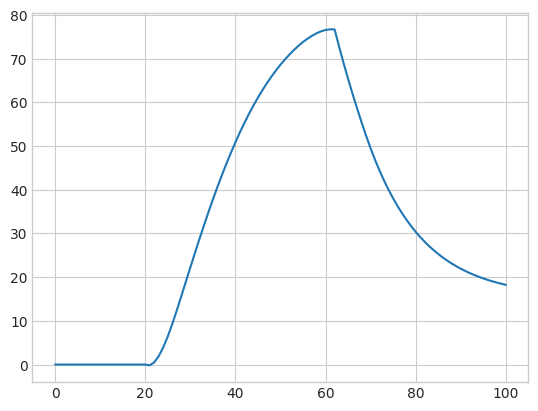

In [14]:
plt.plot(ss_results['c_vec'])
plt.show()
plt.plot(ss_results['b_vec'])

## Rest of params


The initial steady state is in the year $2025$, the resulting steady state is in the year $2100$.

Starting Steady State Solver (Mode: fix_tax, Tax: tau_l)...
Iter 0: Error=0.375550
  guesses: r=0.0500 | BQ=0.2000 | PolVar=0.2200
  implied: r_new=0.1008 | BQ_new=0.1200 | policy_new=0.5955
  aggregates: Y=0.7075 | K=2.1101 | L=0.2026 | C=0.7737 | w=2.9157
---------------------------------------------------------------------------
Iter 20: Error=0.072760
  guesses: r=0.0722 | BQ=0.1970 | PolVar=0.4103
  implied: r_new=0.0788 | BQ_new=0.2320 | policy_new=0.4831
  aggregates: Y=0.7546 | K=2.7043 | L=0.1922 | C=0.7778 | w=2.4933
---------------------------------------------------------------------------
Iter 40: Error=0.022349
  guesses: r=0.0753 | BQ=0.2283 | PolVar=0.4462
  implied: r_new=0.0764 | BQ_new=0.2506 | policy_new=0.4575
  aggregates: Y=0.7394 | K=2.7101 | L=0.1856 | C=0.8015 | w=2.4455
---------------------------------------------------------------------------
Iter 60: Error=0.007303
  guesses: r=0.0759 | BQ=0.2426 | PolVar=0.4503
  implied: r_new=0.0761 | BQ_new=0.2499 | po

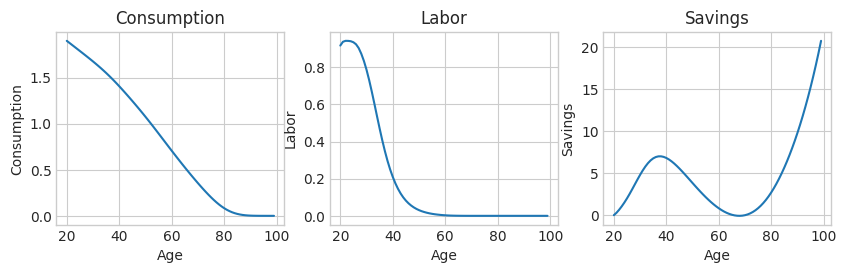

-----------------------------------------


In [126]:
g_n = omega.loc[2025].sum() / omega.loc[2024].sum() - 1
params = {
    'A': 1.4,
    'alpha': .39,
    'delta': .03,
    'tau_c': 0.,
    'tau_l': .22,
    'tau_k': 0.,
    'R': 62,
    'E': 20,
    'S': 100,
    'g_n': g_n,
    'g_y': .02,
    'beta': .95,
    'sigma': 1.97,
    'replacement_rate': .3,
    'ltilde': 1.,
    'b_ellip': .4309,
    'upsilon': 1.7648,
    'chi_s': chi_s,
    'h': 0.0,
}

# Normalizing population to 1 for convenience
pop_base = omega.iloc[:, :].sum(axis=1)
omega_norm = omega.div(pop_base, axis=0)
I_norm = I.div(pop_base, axis=0)

vectors = {
    'omega': omega_norm.loc[2025][:-1].values,
    'rho': rho.loc[2025].values,
    'i_rate': i[:-1].values,
    'I_total': I_norm.loc[2025].values,
}

solver_params = {
    'r_guess': 0.05,
    'BQ_guess': 0.2,
    'tax_guess': .22,
    'policy_mode': 'fix_tax',
    'tax_type': 'tau_l',
    'xi': 0.05,
    'tol': 1e-4,
    'max_iter': 250,
    'debug': True
}

reimport()

steady_state = SteadyStateEquilibrium(params, vectors)
ss_results = steady_state.solve(**solver_params)